In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from google.colab import files
uploaded = files.upload()

Saving 깔끔한방vs지저분한방.zip to 깔끔한방vs지저분한방.zip


In [9]:
!unzip -q "/content/깔끔한방vs지저분한방.zip" -d /content/dataset

replace /content/dataset/1/val/messy/8.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/test/clean/1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/val/messy/3.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/test/clean/0.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/val/messy/9.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/val/messy/5.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/val/messy/7.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/test/messy/2.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/test/clean/6.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/test/messy/8.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/test/clean/3.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/1/test/clean/9.png? [y]es, [n]o, [A]ll, [N]on

In [12]:
!ls /content/dataset/1

test  train  val


In [17]:
!ls /content/dataset/1/

test  train  val


In [16]:
!ls /content/dataset/1/train/

clean  messy


In [18]:
!ls /content/dataset/1/train/clean/

0.png	19.png	28.png	37.png	46.png	55.png	64.png	73.png	82.png	91.png
10.png	1.png	29.png	38.png	47.png	56.png	65.png	74.png	83.png	92.png
11.png	20.png	2.png	39.png	48.png	57.png	66.png	75.png	84.png	93.png
12.png	21.png	30.png	3.png	49.png	58.png	67.png	76.png	85.png	94.png
13.png	22.png	31.png	40.png	4.png	59.png	68.png	77.png	86.png	95.png
14.png	23.png	32.png	41.png	50.png	5.png	69.png	78.png	87.png	9.png
15.png	24.png	33.png	42.png	51.png	60.png	6.png	79.png	88.png
16.png	25.png	34.png	43.png	52.png	61.png	70.png	7.png	89.png
17.png	26.png	35.png	44.png	53.png	62.png	71.png	80.png	8.png
18.png	27.png	36.png	45.png	54.png	63.png	72.png	81.png	90.png


In [2]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models

In [3]:
# 이미지를 출력하는 함수
def display_images(image_paths, title, max_images=4):
  """지정된 경로의 이미지를 최대 4개까지 출력합니다."""
  plt.figure(figsize=(12,3))
  for i, image_path in enumerate(image_paths[:max_images]):
    img = plt.imread(image_path)
    plt.subplot(1, max_images, i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
  plt.show()

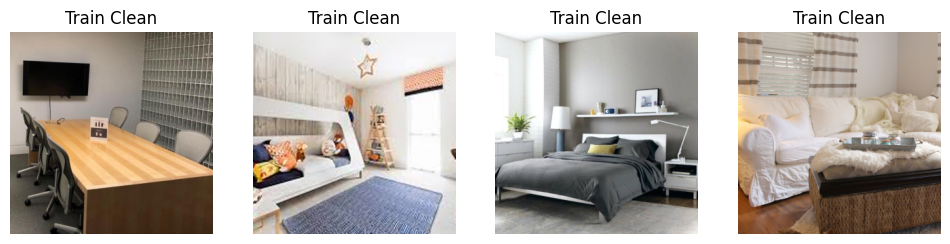

Train Clean 총 이미지 수: 96


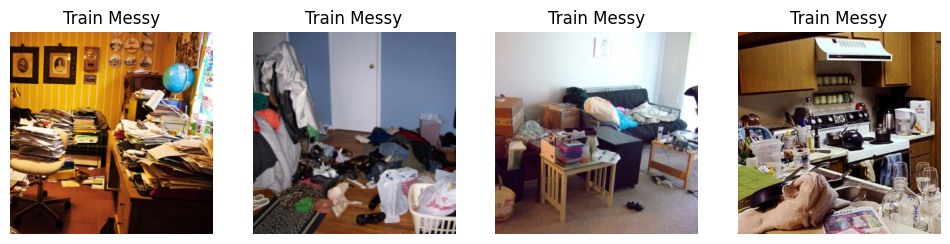

Train Messy 총 이미지 수: 96


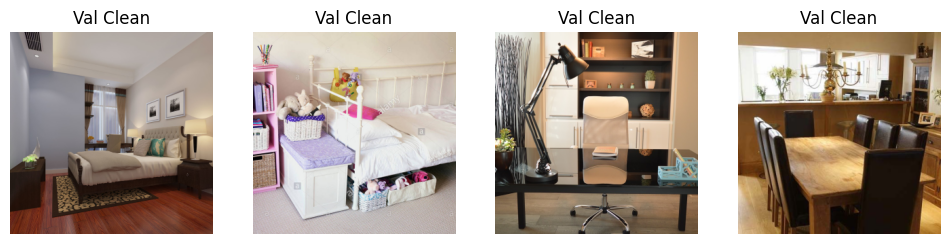

Val Clean 총 이미지 수: 10


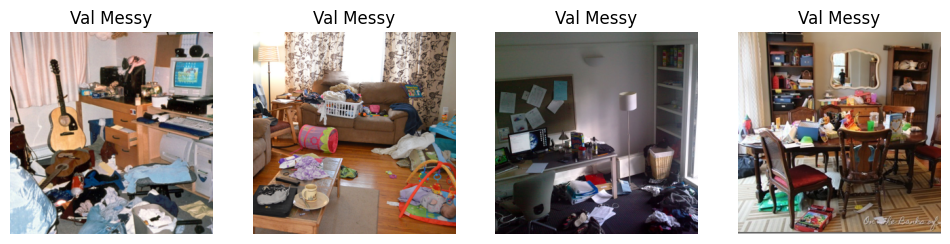

Val Messy 총 이미지 수: 10


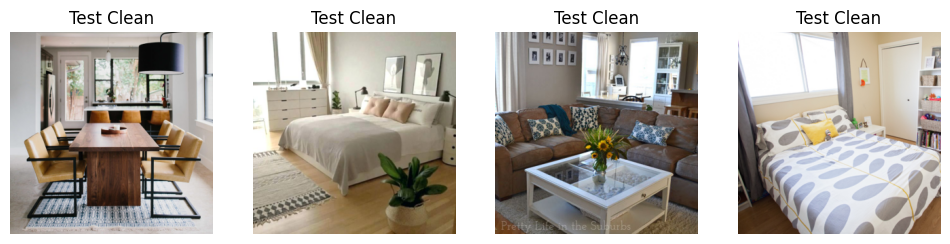

Test Clean 총 이미지 수: 5


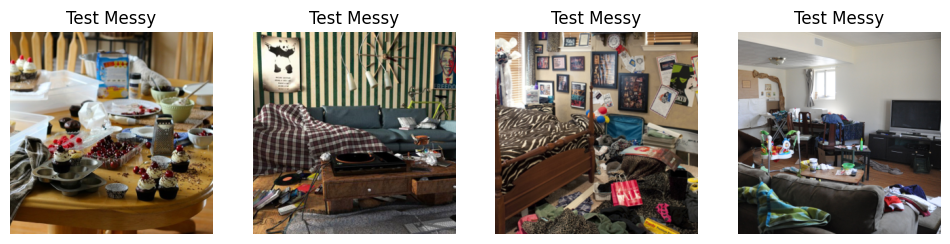

Test Messy 총 이미지 수: 5


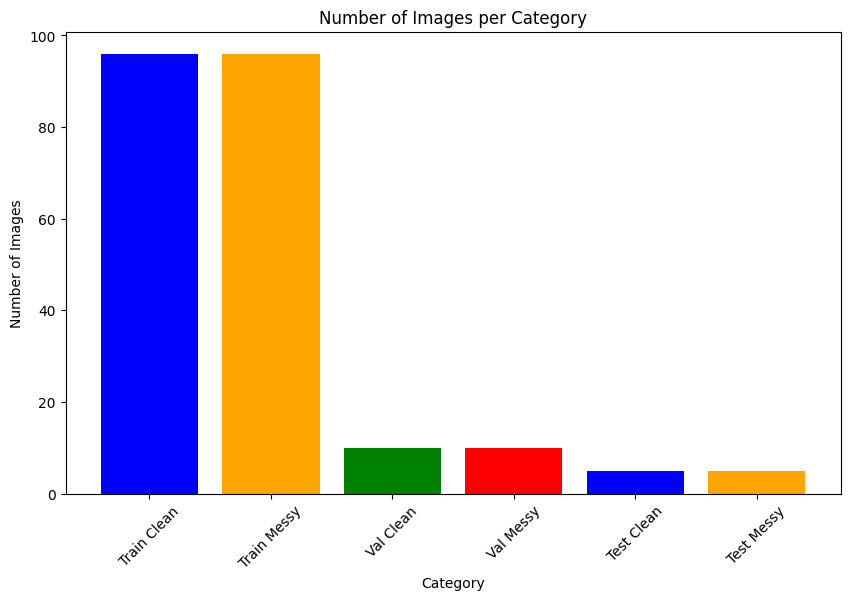

In [19]:
# 이미지와 바 그래프 출력
categories = ['Train Clean', 'Train Messy', 'Val Clean', 'Val Messy', 'Test Clean', 'Test Messy']
for category in categories:
  image_paths = glob.glob(f'/content/dataset/1/{category.lower().replace(" ","/")}/*')
  display_images(image_paths, category)
  print(f"{category} 총 이미지 수: {len(image_paths)}")

# 바 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(categories, [len(glob.glob(f'/content/dataset/1/{category.lower().replace(" ","/")}/*')) for category in categories], color=['blue','orange','green','red'])
plt.title('Number of Images per Category')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [20]:
# 데이터 전처리 정의
transform = transforms.Compose([
    transforms.Resize((224, 224)), # 이미지 크기 조정
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # 정규화
])

# 데이터셋 로드 및 데이터 로더 생성
train_dataset = ImageFolder('/content/dataset/1/train',transform=transform)
val_dataset = ImageFolder('/content/dataset/1/val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [21]:
# AlexNet 모델 로드 및 네트워크 구조 확인
net = models.alexnet(pretrained=True)
net

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 190MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [22]:
# 모델의 모든 파라미터 고정
for param in net.parameters():
  param.requires_grad = False

In [23]:
# classifier의 마지막 레이어를 Binary Classification Task에 맞게 교체하고, 이 레이어의 파라미터는 학습 가능하도록 설정
net.classifier[6] = nn.Linear(4096,2)

net.classifier[5].requires_grad = True
net.classifier[6].requires_grad = True

In [24]:
# 손실 함수 및 최적화기
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.0001)

In [25]:
# 정확도 계산 함수
def calculate_accuracy(loader, model):
  """주어진 데이터 로더에 대한 모델의 정확도를 계산합니다."""
  model.eval() # 모델을 평가 모드로 설정
  correct = 0  # 맞춘 개수 저장
  total = 0    # 전체 데이터 개수 저장
  with torch.no_grad(): # 평가할 때는 gradient 계산 불필요 -> 메모리와 연산량 절약
    for data in loader: # DataLoader에서 배치 단위로 데이터를 가져옴
      images, labels = data  # 입력 데이터(images) 와 정답(labels)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  return 100 * correct / total

In [26]:
# 학습/검증 손실과 검증 정확도를 저장할 리스트
train_losses = []
val_losses = []
val_accuracies = []

# 모델 학습
num_epochs = 5
for epoch in range(num_epochs):
  net.train() # 모델을 학습 모드로 설정
  running_loss = 0.0
  for i, data in enumerate(train_loader):
    inputs, labels = data               # 입력 데이터와 정답 라벨 분리
    optimizer.zero_grad()               # 기울기(gradient) 초기화
    outputs = net(inputs)               # 모델에 입력을 넣어 출력(예측) 계산
    loss = criterion(outputs, labels)   # 출력과 정답 비교하여 손실 계산
    loss.backward()                     # 역전파 -> 기울기 계산
    optimizer.step()                    # 기울기를 이용해 파라미터 업데이트
    running_loss += loss.item()         # 이번 배치 손실을 누적함에 더하기

  train_loss = running_loss / len(train_loader)
  train_losses.append(train_loss)


  val_loss = 0.0
  net.eval()
  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = net(inputs)
      loss = criterion(outputs, labels)
      val_loss += loss.item()


  val_loss /= len(val_loader)
  val_losses.append(val_loss)

  val_accuray = calculate_accuracy(val_loader, net)
  val_accuracies.append(val_accuray)

  print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuray:.2f}%")

print('Finished Training')

Epoch 1/5, Train Loss: 0.5872, Val Loss: 0.3523, Val Accuracy: 95.00%
Epoch 2/5, Train Loss: 0.3428, Val Loss: 0.2209, Val Accuracy: 100.00%
Epoch 3/5, Train Loss: 0.2682, Val Loss: 0.1792, Val Accuracy: 100.00%
Epoch 4/5, Train Loss: 0.2185, Val Loss: 0.1381, Val Accuracy: 100.00%
Epoch 5/5, Train Loss: 0.1904, Val Loss: 0.1204, Val Accuracy: 100.00%
Finished Training


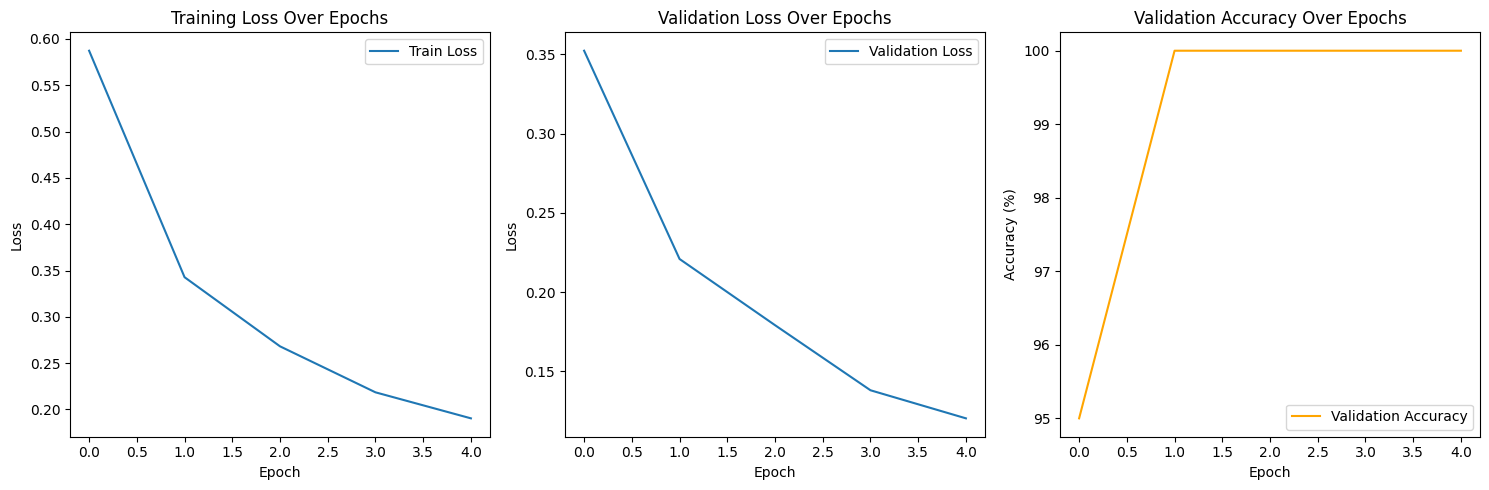

In [27]:
# 학습 손실과 검증 정확도 그래프 그리기
plt.figure(figsize=(15, 5))

# 학습 손실 그래프
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# 검증 정확도 그래프
plt.subplot(1, 3, 2)
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()

# 검증 정확도 그래프
plt.subplot(1, 3, 3)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
def load_and_transform_image(image_path, transform):
  image = Image.open(image_path).convert('RGB')
  return transform(image).unsqueeze(0) # 이미지를 모델에 맞게 변환하고 배치 차원 추가

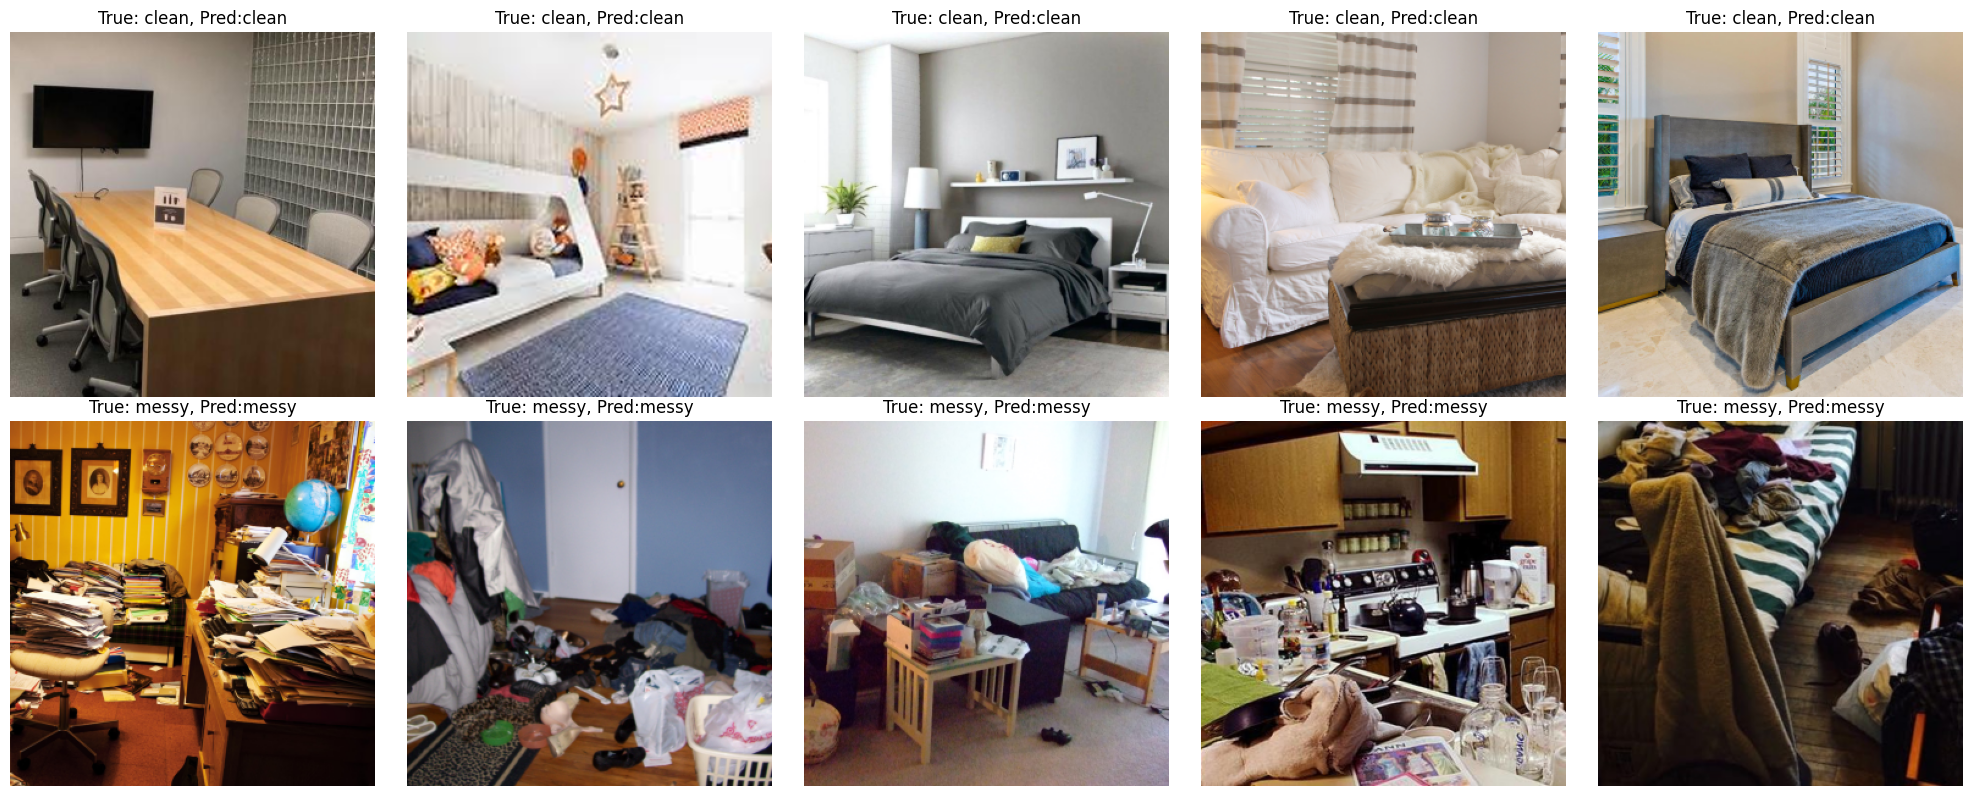

In [31]:
# 클래스별 폴더 경로
class_folders = {
    'clean': '/content/dataset/1/train/clean/',
    'messy': '/content/dataset/1/train/messy/'
}

plt.figure(figsize=(20,8))
counter = 1

# 각 클래스별로 5장의 이미지 추론 및 시각화
for class_name, folder_path in class_folders.items():
  # 해당 클래스의 이미지 경로 가져오기
  image_paths = glob.glob(os.path.join(folder_path, '*'))
  selected_paths = image_paths[:5]

  for image_path in selected_paths:
    image = load_and_transform_image(image_path, transform)

    net.eval()
    with torch.no_grad():
      outputs = net(image)
      _, predicted = torch.max(outputs, 1)
    prediction = 'clean' if predicted.item() == 0 else 'messy'

    # 결과 시각화
    plt.subplot(2, 5, counter)
    plt.imshow(Image.open(image_path))
    plt.title(f'True: {class_name}, Pred:{prediction}')
    plt.axis('off')

    counter += 1

plt.tight_layout()
plt.show()